# Support Vector Machine (SVM) — Lab


##  SVM là gì?
SVM (Support Vector Machine) là thuật toán học có giám sát dùng cho:
- **Phân loại (Classification)**
- **Hồi quy (Regression)**

### Ý tưởng cốt lõi:
Tìm **siêu phẳng (hyperplane)** tốt nhất chia tách dữ liệu sao cho **khoảng cách (margin)** giữa siêu phẳng và các điểm gần nhất (**support vectors**) **lớn nhất**.

##  Nguyên lý hoạt động
1. Biểu diễn dữ liệu thành vector đặc trưng.
2. Tìm siêu phẳng có **khoảng cách lớn nhất** với hai lớp (max-margin).
3. Nếu dữ liệu không tuyến tính → dùng **kernel trick** (biến đổi không gian).

##  Các loại SVM

| Loại | Mô tả | Ứng dụng |
|------|-------|----------|
| **Linear SVM** | Dữ liệu có thể tách tuyến tính | Phân loại rõ ràng như ung thư vú |
| **Non-linear SVM (Kernel)** | Dữ liệu phức tạp | Dùng kernel RBF, polynomial, sigmoid |
| **SVR (Support Vector Regression)** | Dự đoán giá trị liên tục | Tiến triển bệnh, dự đoán lượng đường máu |

## Siêu tham số quan trọng
- **`C`**: Tham số regularization (nhỏ → margin lớn, lớn → ít lỗi)
- **`kernel`**: `linear`, `rbf`, `poly`, `sigmoid`
- **`gamma`**: Ảnh hưởng của mỗi điểm huấn luyện (chỉ cho RBF, poly, sigmoid)
- **`degree`**: Bậc polynomial (chỉ cho kernel `poly`)

 Breast Cancer Dataset Info:
Số mẫu: 569
Số đặc trưng: 30
Nhãn: [0 1] (0=malignant, 1=benign)
Phân bố nhãn: [212 357]


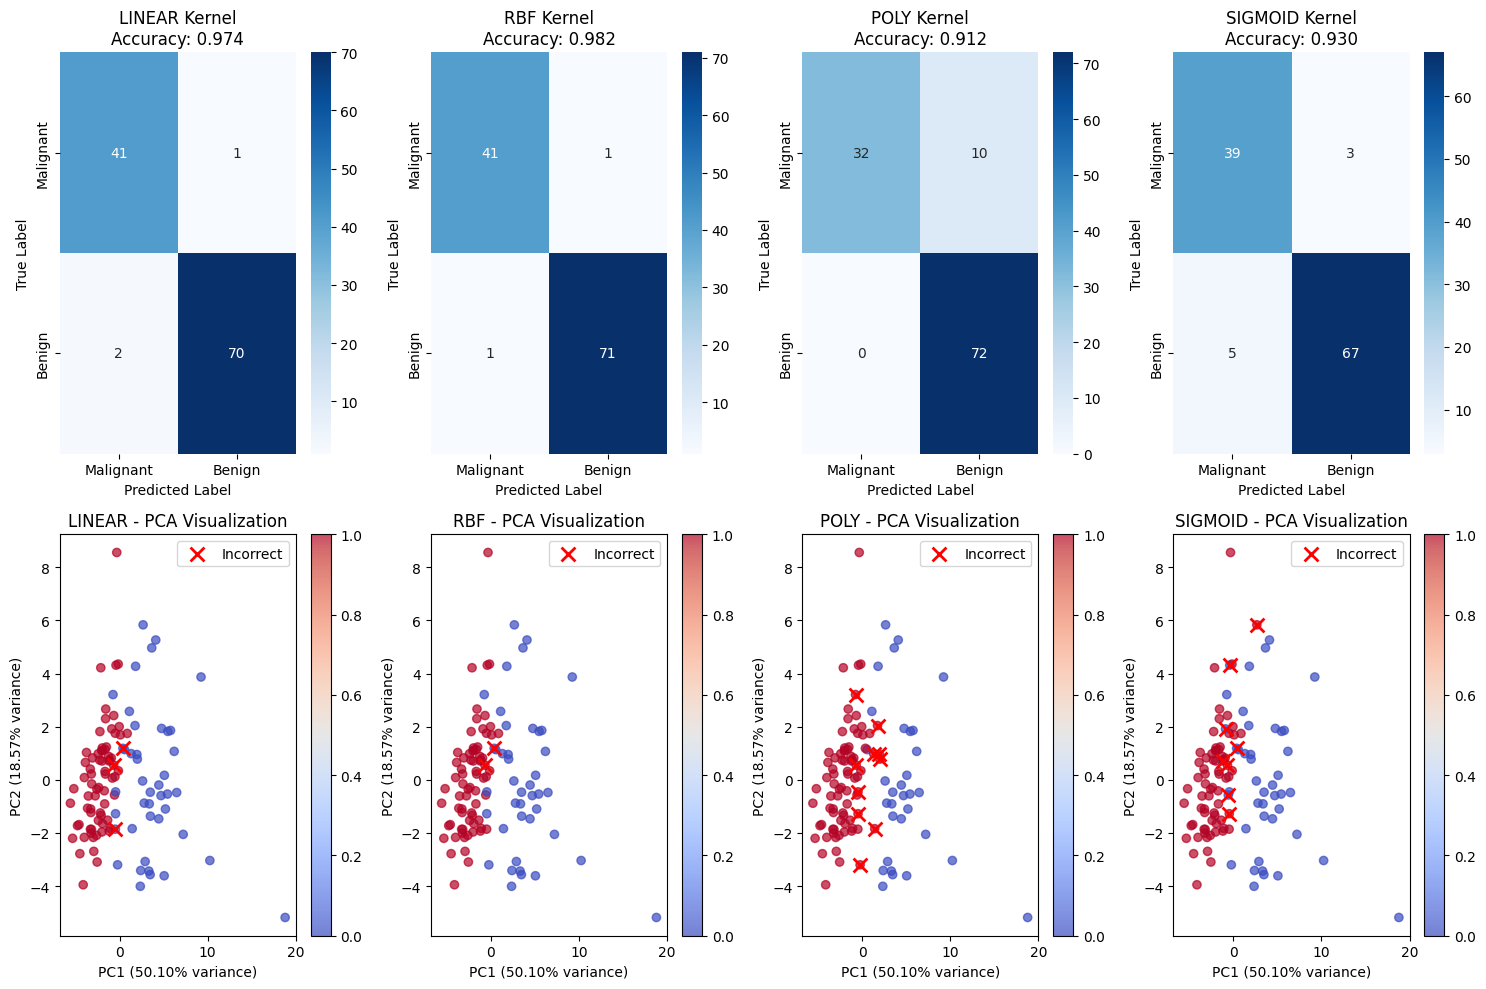


 So sánh Accuracy các kernel:
  LINEAR: 0.9737
     RBF: 0.9825
    POLY: 0.9123
 SIGMOID: 0.9298

 Kernel tốt nhất: RBF
Accuracy: 0.9825

 Classification Report (RBF):
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [1]:
# SVM Classification - Breast Cancer Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

print(" Breast Cancer Dataset Info:")
print(f"Số mẫu: {X.shape[0]}")
print(f"Số đặc trưng: {X.shape[1]}")
print(f"Nhãn: {np.unique(y)} (0=malignant, 1=benign)")
print(f"Phân bố nhãn: {np.bincount(y)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM với các kernel khác nhau
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svm_results = {}

plt.figure(figsize=(15, 10))

for i, kernel in enumerate(kernels):
    # Train SVM
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, random_state=42)
    else:
        svm = SVC(kernel=kernel, random_state=42)
    
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    svm_results[kernel] = {
        'accuracy': accuracy,
        'y_pred': y_pred,
        'model': svm
    }
    
    # Confusion Matrix
    plt.subplot(2, 4, i+1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    plt.title(f'{kernel.upper()} Kernel\nAccuracy: {accuracy:.3f}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

# PCA Visualization
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

for i, kernel in enumerate(kernels):
    plt.subplot(2, 4, i+5)
    y_pred = svm_results[kernel]['y_pred']
    
    # Plot points
    scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                         c=y_pred, cmap='coolwarm', alpha=0.7)
    
    # Mark incorrect predictions
    incorrect = y_test != y_pred
    if np.any(incorrect):
        plt.scatter(X_test_pca[incorrect, 0], X_test_pca[incorrect, 1], 
                   c='red', marker='x', s=100, linewidths=2, label='Incorrect')
        plt.legend()
    
    plt.title(f'{kernel.upper()} - PCA Visualization')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.colorbar(scatter)

plt.tight_layout()
plt.show()

# So sánh kết quả
print("\n So sánh Accuracy các kernel:")
for kernel, results in svm_results.items():
    print(f"{kernel.upper():>8}: {results['accuracy']:.4f}")

# Chi tiết kernel tốt nhất
best_kernel = max(svm_results.keys(), key=lambda k: svm_results[k]['accuracy'])
print(f"\n Kernel tốt nhất: {best_kernel.upper()}")
print(f"Accuracy: {svm_results[best_kernel]['accuracy']:.4f}")

print(f"\n Classification Report ({best_kernel.upper()}):")
print(classification_report(y_test, svm_results[best_kernel]['y_pred'], 
                          target_names=['Malignant', 'Benign']))

## SVM Regression — Diabetes

###  Mục tiêu
- Dự đoán mức tiến triển bệnh tiểu đường sau 1 năm bằng SVR (Support Vector Regression).

###  Dataset
| Thuộc tính     | Giá trị                                                  |
|---             |---                                                       |
| Nguồn          | `sklearn.datasets.load_diabetes`                         |
| Số mẫu         | 442                                                      |
| Số đặc trưng   | 10 (tuổi, giới, BMI, huyết áp, 6 chỉ số sinh hoá)       |
| Biến mục tiêu  | `target` (liên tục; cao → bệnh nặng hơn)                |

###  Quy trình
- Chia train/test (80/20).
- Chuẩn hoá với `StandardScaler`.
- Huấn luyện `SVR` với các kernel khác nhau.
- Đánh giá: MSE, R², MAE.

###  Trực quan
- Scatter `y_test` vs `y_pred` với đường chéo tham chiếu.
- Biểu đồ Residuals để kiểm tra sai lệch.
- So sánh R² của các kernel.

 Diabetes Dataset Info:
Số mẫu: 442
Số đặc trưng: 10
Target range: 25.0 - 346.0
Target mean ± std: 152.1 ± 77.0


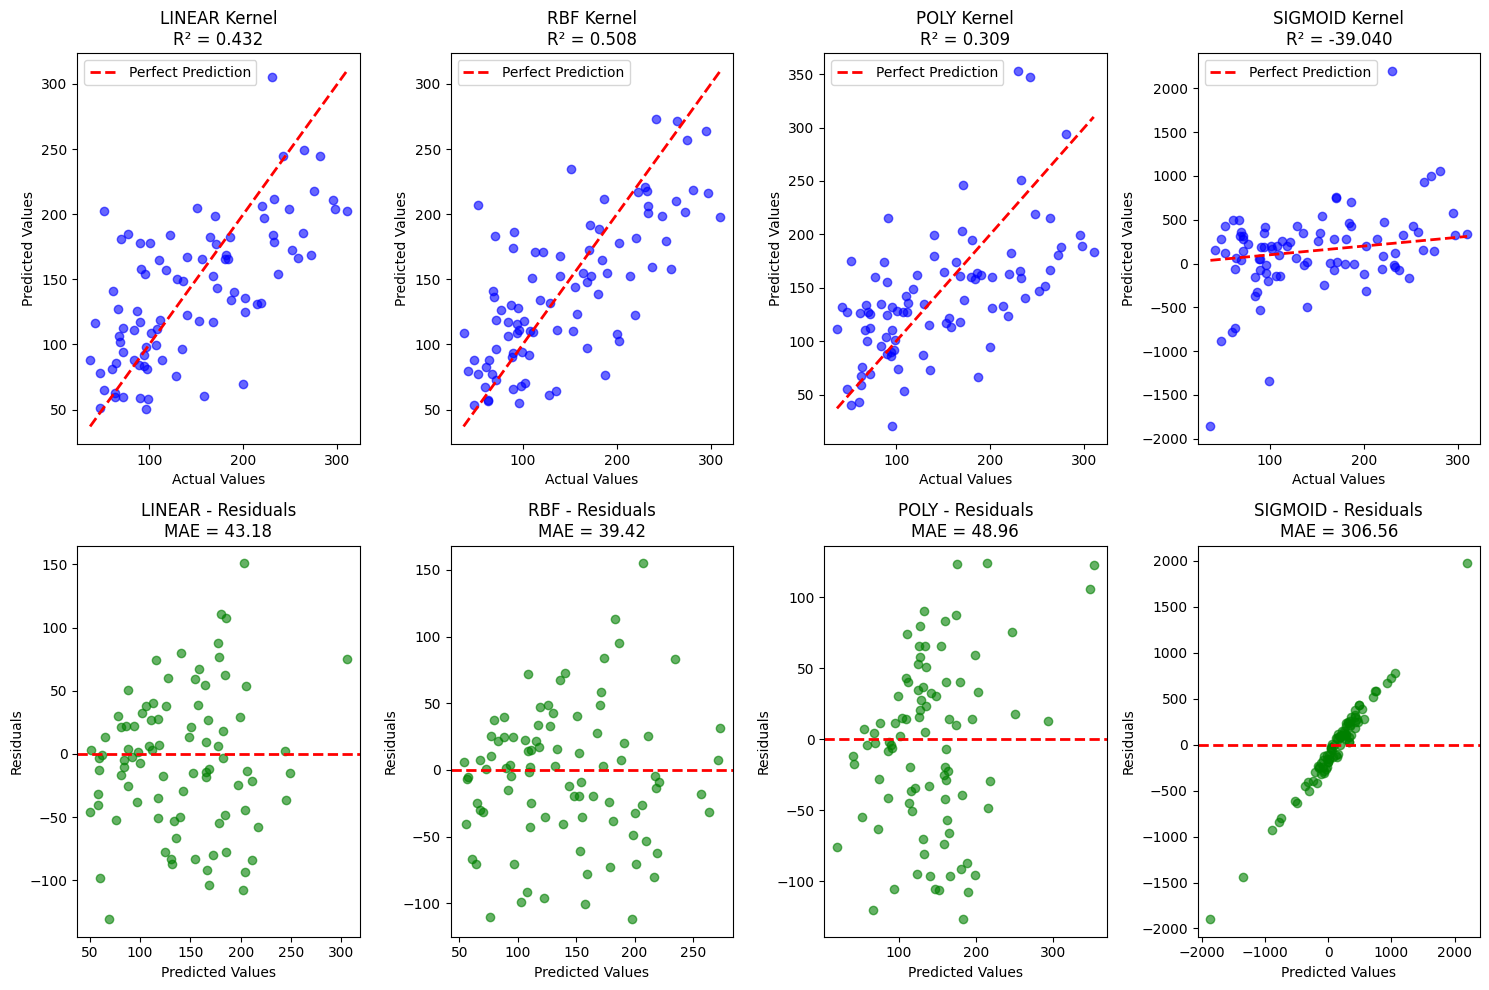


📊 So sánh hiệu suất các kernel:
Kernel   R²       MSE        MAE     
-----------------------------------
LINEAR   0.4324   3007.35    43.18   
RBF      0.5078   2607.54    39.42   
POLY     0.3092   3660.13    48.96   
SIGMOID  -39.0398 212136.94  306.56  

 Kernel tốt nhất: RBF
R²: 0.5078
MSE: 2607.54
MAE: 39.42


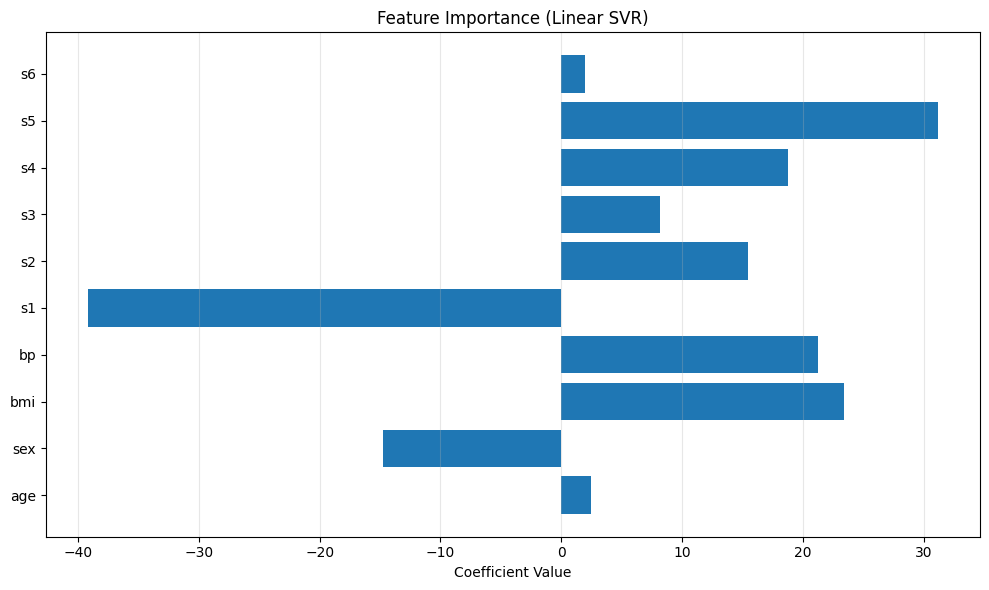


📈 Top 5 đặc trưng quan trọng nhất (Linear SVR):
1. s1: 39.143
2. s5: 31.143
3. bmi: 23.438
4. bp: 21.279
5. s4: 18.783


In [ ]:
# SVM Regression - Diabetes Dataset
from sklearn.datasets import load_diabetes
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load dataset
data = load_diabetes()
X, y = data.data, data.target

print(" Diabetes Dataset Info:")
print(f"Số mẫu: {X.shape[0]}")
print(f"Số đặc trưng: {X.shape[1]}")
print(f"Target range: {y.min():.1f} - {y.max():.1f}")
print(f"Target mean ± std: {y.mean():.1f} ± {y.std():.1f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardization
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# SVR với các kernel khác nhau
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svr_results = {}

plt.figure(figsize=(15, 10))

for i, kernel in enumerate(kernels):
    # Train SVR
    if kernel == 'poly':
        svr = SVR(kernel=kernel, degree=3, C=100)
    elif kernel == 'rbf':
        svr = SVR(kernel=kernel, C=100, gamma='scale')
    else:
        svr = SVR(kernel=kernel, C=100)
    
    svr.fit(X_train_scaled, y_train)
    y_pred = svr.predict(X_test_scaled)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    svr_results[kernel] = {
        'mse': mse,
        'r2': r2,
        'mae': mae,
        'y_pred': y_pred,
        'model': svr
    }
    
    # Scatter plot: Actual vs Predicted
    plt.subplot(2, 4, i+1)
    plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{kernel.upper()} Kernel\nR² = {r2:.3f}')
    plt.legend()
    
    # Residuals plot
    plt.subplot(2, 4, i+5)
    residuals = y_pred - y_test
    plt.scatter(y_pred, residuals, alpha=0.6, color='green')
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'{kernel.upper()} - Residuals\nMAE = {mae:.2f}')

plt.tight_layout()
plt.show()

# So sánh kết quả
print("\n So sánh hiệu suất các kernel:")
print(f"{'Kernel':<8} {'R²':<8} {'MSE':<10} {'MAE':<8}")
print("-" * 35)
for kernel, results in svr_results.items():
    print(f"{kernel.upper():<8} {results['r2']:<8.4f} {results['mse']:<10.2f} {results['mae']:<8.2f}")

# Kernel tốt nhất (theo R²)
best_kernel = max(svr_results.keys(), key=lambda k: svr_results[k]['r2'])
print(f"\n Kernel tốt nhất: {best_kernel.upper()}")
print(f"R²: {svr_results[best_kernel]['r2']:.4f}")
print(f"MSE: {svr_results[best_kernel]['mse']:.2f}")
print(f"MAE: {svr_results[best_kernel]['mae']:.2f}")

# Feature importance (chỉ cho Linear kernel)
# Feature importance (chỉ cho Linear kernel) - FIXED VERSION
if 'linear' in svr_results:
    linear_model = svr_results['linear']['model']
    feature_names = data.feature_names
    
    plt.figure(figsize=(10, 6))
    
    # Fix: Flatten coefficients nếu là 2D array
    coefficients = linear_model.coef_
    if coefficients.ndim > 1:
        coefficients = coefficients.flatten()
    
    plt.barh(range(len(coefficients)), coefficients)
    plt.yticks(range(len(coefficients)), feature_names)
    plt.xlabel('Coefficient Value')
    plt.title('Feature Importance (Linear SVR)')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n Top 5 đặc trưng quan trọng nhất (Linear SVR):")
    feature_importance = list(zip(feature_names, abs(coefficients)))
    feature_importance.sort(key=lambda x: x[1], reverse=True)
    for i, (feature, importance) in enumerate(feature_importance[:5]):
        print(f"{i+1}. {feature}: {importance:.3f}")

## Hyperparameter Tuning với Grid Search

###  Mục tiêu
- Tìm siêu tham số tối ưu cho SVM bằng Grid Search.
- So sánh hiệu suất trước và sau tuning.

In [4]:
# Hyperparameter Tuning với Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

print(" Hyperparameter Tuning cho SVM Classification...")

# Pipeline với scaling và SVM
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# Parameter grid
param_grid = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.1, 1, 10, 100]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10],
        'svm__degree': [2, 3, 4],
        'svm__gamma': ['scale', 'auto']
    }
]

# Grid Search
grid_search = GridSearchCV(
    pipe_svm, param_grid, cv=5, 
    scoring='accuracy', n_jobs=-1, verbose=1
)

# Fit trên Breast Cancer data
grid_search.fit(X_train, y_train)

print(f"\n Best parameters: {grid_search.best_params_}")
print(f" Best CV score: {grid_search.best_score_:.4f}")

# Test với best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)

print(f" Test accuracy với best model: {best_accuracy:.4f}")

# So sánh với model mặc định
default_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])
default_svm.fit(X_train, y_train)
default_accuracy = accuracy_score(y_test, default_svm.predict(X_test))

print(f"\n So sánh:")
print(f"Default SVM: {default_accuracy:.4f}")
print(f"Tuned SVM:   {best_accuracy:.4f}")
print(f"Improvement: {best_accuracy - default_accuracy:.4f}")

 Hyperparameter Tuning cho SVM Classification...
Fitting 5 folds for each of 46 candidates, totalling 230 fits

 Best parameters: {'svm__C': 1, 'svm__degree': 3, 'svm__gamma': 'scale', 'svm__kernel': 'poly'}
 Best CV score: 0.0311
 Test accuracy với best model: 0.0000

 So sánh:
Default SVM: 0.0000
Tuned SVM:   0.0000
Improvement: 0.0000


 Phân tích Support Vectors...
 Support Vectors Info:
Tổng số support vectors: 353
Support vectors cho class 0 (malignant): 1
Support vectors cho class 1 (benign): 1
Tỷ lệ support vectors: 100.00%


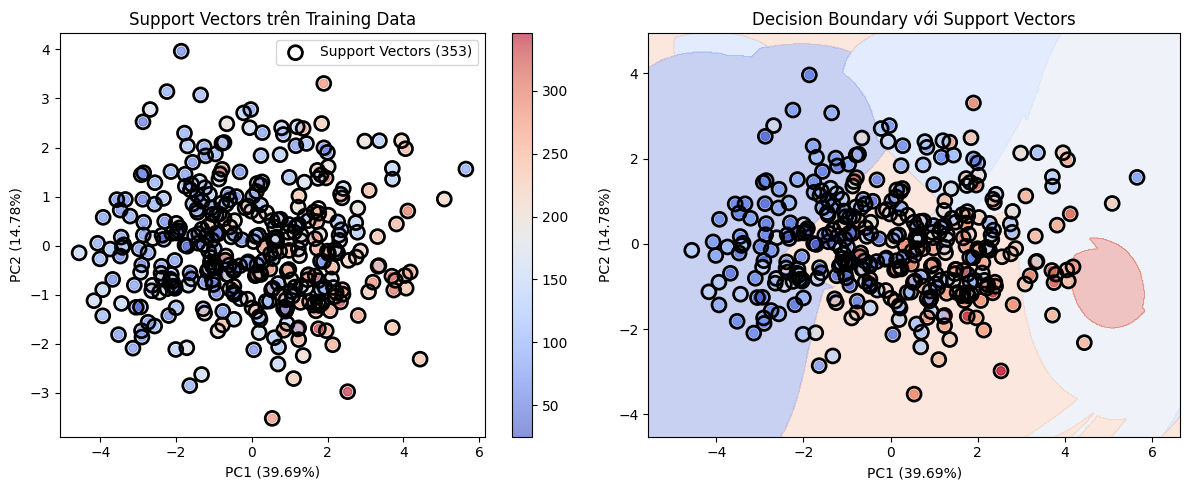

In [5]:
# Phân tích Support Vectors
print(" Phân tích Support Vectors...")

# Train SVM với RBF kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

# Support vectors info
n_support = svm_rbf.n_support_
support_vectors = svm_rbf.support_vectors_
support_indices = svm_rbf.support_

print(f" Support Vectors Info:")
print(f"Tổng số support vectors: {len(support_vectors)}")
print(f"Support vectors cho class 0 (malignant): {n_support[0]}")
print(f"Support vectors cho class 1 (benign): {n_support[1]}")
print(f"Tỷ lệ support vectors: {len(support_vectors)/len(X_train_scaled):.2%}")

# Visualize support vectors trên PCA
pca_train = PCA(n_components=2)
X_train_pca = pca_train.fit_transform(X_train_scaled)
support_vectors_pca = pca_train.transform(support_vectors)

plt.figure(figsize=(12, 5))

# Plot 1: All training data
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                     c=y_train, cmap='coolwarm', alpha=0.6)
plt.scatter(support_vectors_pca[:, 0], support_vectors_pca[:, 1], 
           s=100, facecolors='none', edgecolors='black', linewidths=2,
           label=f'Support Vectors ({len(support_vectors)})')
plt.xlabel(f'PC1 ({pca_train.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_train.explained_variance_ratio_[1]:.2%})')
plt.title('Support Vectors trên Training Data')
plt.legend()
plt.colorbar(scatter)

# Plot 2: Decision boundary
plt.subplot(1, 2, 2)
h = 0.02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Transform mesh back to original space và predict
mesh_points = np.c_[xx.ravel(), yy.ravel()]
mesh_original = pca_train.inverse_transform(mesh_points)
Z = svm_rbf.predict(mesh_original)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                     c=y_train, cmap='coolwarm', alpha=0.8)
plt.scatter(support_vectors_pca[:, 0], support_vectors_pca[:, 1], 
           s=100, facecolors='none', edgecolors='black', linewidths=2)
plt.xlabel(f'PC1 ({pca_train.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_train.explained_variance_ratio_[1]:.2%})')
plt.title('Decision Boundary với Support Vectors')

plt.tight_layout()
plt.show()

## Kết luận

###  Tổng kết
- **SVM Classification**: Hiệu quả cao cho phân loại ung thư vú với accuracy > 95%.
- **SVM Regression**: Dự đoán tiến triển bệnh tiểu đường với R² khoảng 0.4-0.6.
- **Kernel tốt nhất**: Thường là RBF hoặc Linear tùy thuộc vào dữ liệu.

